In [1]:
import torch
import pickle
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from foldCV import single_iteration

In [2]:
# similarity metric for knowledge-alignment loss (e.g., euclidean, cosine)
metric = 'cosine'

# hyperparameter lambda of knowledge-alignment loss
lambda_KAL = [0, 1e-3, 1e-2, 1e-1, 1e-0, 1e+1]

# Simulation Data
with open("./data/simulation_data.pickle","rb") as fr:
    data = pickle.load(fr)

X = torch.tensor(data['X'], dtype=torch.float32)
y = torch.tensor(data['y'], dtype=torch.float32)

# K-fold setting
with open("./data/5fold_setting.pickle","rb") as fr:
    fold_setting = pickle.load(fr)

# Knowledge Guided Features: x1, x2, x3
knowledge_index = np.array([0,1,2])

# run single 5 fold CV pipeline
eval_dic = single_iteration(X = X, y = y,
                            fold_setting = fold_setting,
                            knowledge_index = knowledge_index,
                            lambda_KAL = [0, 1e-3, 1e-2, 1e-1, 1e-0, 1e+1],
                            metric = metric)

lambda_KAL (0): 1.0521
lambda_KAL (0.001): 0.8739
lambda_KAL (0.01): 0.706
lambda_KAL (0.1): 0.6598
lambda_KAL (1.0): 0.484
lambda_KAL (10.0): 0.5794


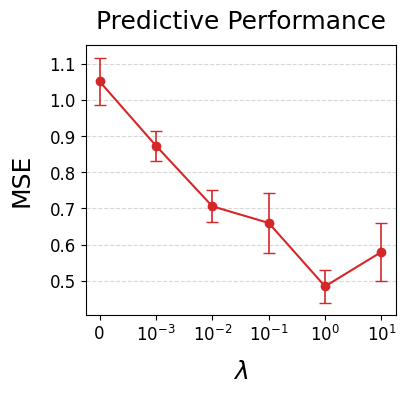

In [4]:
MSEs = np.array([[eval_dic[lambda_KAL][k]['MSE']['test'] for k in range(5)] for lambda_KAL in [0, 1e-3, 1e-2, 1e-1, 1e-0, 1e+1]])
MSE  = [i.mean() for i in MSEs]
MSE_err  = [i.std()/(5**0.5) for i in MSEs]

plt.figure(figsize=(4, 3.5))
plt.errorbar(
    range(6), MSE, yerr=MSE_err,
    marker='o', c='#d62728',
    capsize=4, elinewidth=1.2,
    label='Knowledge-based features'
)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylabel('MSE', fontsize = 18, labelpad = 11)
plt.yticks(fontsize = 12)
plt.xticks(range(0,6), ['0']+['$10^{'+str(i)+'}$' for i in list(range(-3,2))], fontsize = 12)
plt.xlabel('$\lambda$', fontsize = 18, labelpad = 11)
plt.title('Predictive Performance', size = 18, pad = 12)
plt.show()

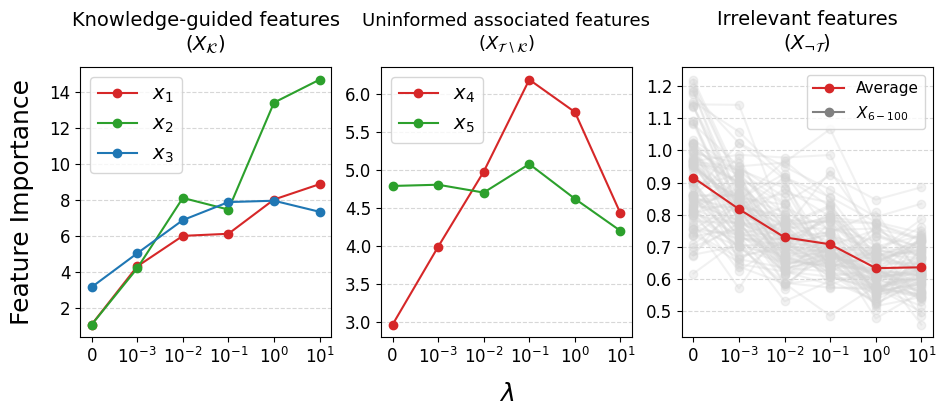

In [5]:
lambda_FI = {}
for lambda_KAL in [0, 1e-3, 1e-2, 1e-1, 1e-0, 1e+1]:
    K_FI = []
    for k in range(5):
        raw_FI = eval_dic[lambda_KAL][k]['Feature_importance'].mean(axis = 0)
        raw_FI = raw_FI/raw_FI.mean()
        K_FI.append(raw_FI.tolist())
    lambda_FI[lambda_KAL] = np.array(K_FI)[np.isnan(np.array(K_FI)).sum(axis = 1) == 0, :]

plt.figure(figsize=(11, 3.5))
colors = ['#d62728', '#2ca02c', '#1f77b4']

plt.subplot(1,3,1)
for ii, x_idx in enumerate([0,1,2]):
    KI_mean = [lambda_FI[lambda_KAL][:,x_idx].mean() for lambda_KAL in [0, 1e-3, 1e-2, 1e-1, 1e-0, 1e+1]]
    plt.plot(KI_mean, marker='o', c=colors[ii], label='$x_{'+str(x_idx+1)+'}$')

plt.legend(fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.yticks(fontsize = 12)
plt.xticks(range(0,6), ['0']+['$10^{'+str(i)+'}$' for i in list(range(-3,2))], fontsize = 12)
plt.title('Knowledge-guided features\n'+r'($X_{\mathcal{K}}$)', size = 14, pad = 13)
plt.ylabel('Feature Importance', fontsize = 18, labelpad = 11)

plt.subplot(1,3,2)
for ii, x_idx in enumerate([3,4]):
    KI_mean = [lambda_FI[lambda_KAL][:,x_idx].mean() for lambda_KAL in [0, 1e-3, 1e-2, 1e-1, 1e-0, 1e+1]]
    plt.plot(KI_mean, marker='o', c=colors[ii], label='$x_{'+str(x_idx+1)+'}$')

plt.legend(fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.yticks(fontsize = 12)
plt.xticks(range(0,6), ['0']+['$10^{'+str(i)+'}$' for i in list(range(-3,2))], fontsize = 12)
plt.title('Uninformed associated features\n'+r'($X_{\mathcal{T} \setminus \mathcal{K}}$)', size = 13, pad = 13)
plt.xlabel('$\lambda$', fontsize = 18, labelpad = 11)

plt.subplot(1,3,3)
for ii, x_idx in enumerate(list(range(5,100))):
    KI_mean = [lambda_FI[lambda_KAL][:,x_idx].mean() for lambda_KAL in [0, 1e-3, 1e-2, 1e-1, 1e-0, 1e+1]]
    plt.plot(KI_mean, c = 'lightgray', marker = 'o', alpha = 0.3)

KI_mean = [lambda_FI[lambda_KAL][:,5:].mean() for lambda_KAL in [0, 1e-3, 1e-2, 1e-1, 1e-0, 1e+1]]
plt.plot(KI_mean, marker='o', c='#d62728', label = 'Average')
plt.plot([], [], marker='o', color='gray', label='$X_{6-100}$')
plt.legend(fontsize = 11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.yticks(fontsize = 12)
plt.xticks(range(0,6), ['0']+['$10^{'+str(i)+'}$' for i in list(range(-3,2))], fontsize = 12)
plt.title('Irrelevant features\n'+r'($X_{\neg\mathcal{T}}$)', size = 14, pad = 13)

plt.show()